<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/LAB16_ARCOS_FRANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

# Esto abrirá un cuadro para que subas los archivos
uploaded = files.upload()

Saving adult.test.csv to adult.test.csv
Saving adult.data.csv to adult.data.csv


In [5]:
# Importar librerías necesarias
import pandas as pd

# Nombres de columnas según la documentación del dataset
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# Cargar los archivos con los nombres corregidos
data_train = pd.read_csv("adult.data.csv", header=None, names=column_names, na_values="?", skipinitialspace=True)
data_test = pd.read_csv("adult.test.csv", header=0, names=column_names, na_values="?", skipinitialspace=True, comment='|')

# Limpiar la columna de income (quitar punto final que aparece en .test)
data_test["income"] = data_test["income"].str.replace(".", "", regex=False)

# Unir ambos datasets
data = pd.concat([data_train, data_test], ignore_index=True)

# Mostrar resumen de datos
data.info()
data.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48841 entries, 0 to 48840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48841 non-null  int64 
 1   workclass       46042 non-null  object
 2   fnlwgt          48841 non-null  int64 
 3   education       48841 non-null  object
 4   education-num   48841 non-null  int64 
 5   marital-status  48841 non-null  object
 6   occupation      46032 non-null  object
 7   relationship    48841 non-null  object
 8   race            48841 non-null  object
 9   sex             48841 non-null  object
 10  capital-gain    48841 non-null  int64 
 11  capital-loss    48841 non-null  int64 
 12  hours-per-week  48841 non-null  int64 
 13  native-country  47984 non-null  object
 14  income          48841 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Preprocesamiento

In [6]:
# Revisar valores nulos
print(data.isnull().sum())

# Imputar datos faltantes (modo para categóricas)
for col in data.select_dtypes(include="object").columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Outliers univariados: usar IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

# Aplicar para algunas variables numéricas
for col in ["age", "hours-per-week", "capital-gain", "capital-loss"]:
    data = remove_outliers(data, col)

# Transformar income a binario
data["income"] = data["income"].map({'>50K': 1, '<=50K': 0})

# Verificación final
data.isnull().sum()


age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


/tmp/ipython-input-6-2338345993.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Information Value (IV) y selección de variables





In [8]:
from sklearn.feature_selection import mutual_info_classif

In [9]:
!pip install -q feature-engine

import pandas as pd
import numpy as np
from feature_engine.discretisation import EqualFrequencyDiscretiser

# Copiar datos
iv_data = data.copy()

# Identificar variables numéricas (excepto income)
num_cols = iv_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('income')

# Discretizar variables numéricas para cálculo de IV
disc = EqualFrequencyDiscretiser(q=5, variables=num_cols)
iv_data = disc.fit_transform(iv_data)

# Función para calcular IV de una variable
def calc_iv(df, feature, target):
    lst = []
    for val in df[feature].unique():
        total = df[df[feature] == val]
        good = total[target].sum()
        bad = total.shape[0] - good
        lst.append([val, good, bad])
    iv_df = pd.DataFrame(lst, columns=['Value', 'Good', 'Bad'])
    iv_df['Good%'] = iv_df['Good'] / iv_df['Good'].sum()
    iv_df['Bad%'] = iv_df['Bad'] / iv_df['Bad'].sum()
    iv_df['WoE'] = np.log(iv_df['Good%'] / iv_df['Bad%']).replace({np.inf: 0, -np.inf: 0})
    iv_df['IV'] = (iv_df['Good%'] - iv_df['Bad%']) * iv_df['WoE']
    return iv_df['IV'].sum()

# Calcular IV de todas las variables excepto income
iv_dict = {}
for col in iv_data.columns:
    if col != 'income':
        iv_dict[col] = calc_iv(iv_data, col, 'income')

# Ordenar IV de mayor a menor
iv_sorted = dict(sorted(iv_dict.items(), key=lambda item: item[1], reverse=True))

# Mostrar
iv_sorted


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


{'relationship': np.float64(1.525392054418637),
 'marital-status': np.float64(1.4200212027411039),
 'age': np.float64(0.6925771043839637),
 'education': np.float64(0.6064594987330193),
 'occupation': np.float64(0.5429936189748292),
 'education-num': np.float64(0.490797648143608),
 'sex': np.float64(0.28381666600187894),
 'hours-per-week': np.float64(0.16494338798273328),
 'workclass': np.float64(0.09888558860217779),
 'native-country': np.float64(0.09415777094305257),
 'race': np.float64(0.08340260901904387),
 'fnlwgt': np.float64(0.0018799549088579113),
 'capital-gain': np.float64(0.0),
 'capital-loss': np.float64(0.0)}

###Calcule el information value (IV) y seleccione las mejores variables, además, aplique un escalamiento a las variables numéricas y convierta las variables categóricas a dummies. Separe los datos en entrenamiento (80%) y prueba (20%) y realice un balanceo de clases


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Selección de variables con IV > 0.02 (ajustable)
selected_features = [k for k, v in iv_sorted.items() if v > 0.02]

# Dummy para categóricas
data_model = pd.get_dummies(data[selected_features + ['income']], drop_first=True)

# Separar variables
X = data_model.drop("income", axis=1)
y = data_model["income"]

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Balancear clases
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)


C) Entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación y Random Forest utilizando hiperparámetros estándar, búsqueda en cuadrícula y búsqueda aleatoria para poder encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Modelos base
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'LogReg': LogisticRegression(max_iter=1000),
    'Tree': DecisionTreeClassifier(),
    'RF': RandomForestClassifier()
}

# Entrenamiento y evaluación inicial
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")


KNN Accuracy: 0.7584
SVM Accuracy: 0.7618
LogReg Accuracy: 0.7763
Tree Accuracy: 0.7848
RF Accuracy: 0.8062


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Definir el espacio de búsqueda
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Inicializar el modelo base
rf = RandomForestClassifier(random_state=42)

# Configurar búsqueda en cuadrícula con validación cruzada (3 folds)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Entrenar sobre datos balanceados
grid_search.fit(X_train_bal, y_train_bal)

# Mostrar mejor combinación de hiperparámetros
print("🎯 Mejores hiperparámetros:")
print(grid_search.best_params_)

# Evaluar sobre el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n✅ Accuracy final en test set:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
🎯 Mejores hiperparámetros:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

✅ Accuracy final en test set: 0.8132244897959183

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      4877
           1       0.54      0.61      0.57      1248

    accuracy                           0.81      6125
   macro avg       0.72      0.74      0.73      6125
weighted avg       0.82      0.81      0.82      6125



In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',  # Muy importante en problemas desbalanceados
    random_state=42
)


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [31]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

In [32]:
model = RandomForestClassifier(class_weight='balanced')

In [33]:
model.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced')

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

/tmp/ipython-input-38-3797714201.py:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


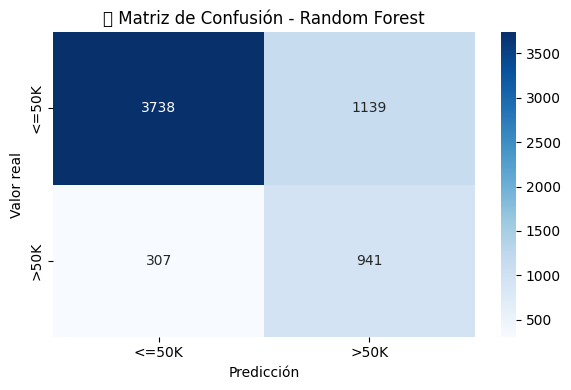

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Dibujarla con etiquetas
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("📊 Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()


/tmp/ipython-input-40-4225771282.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


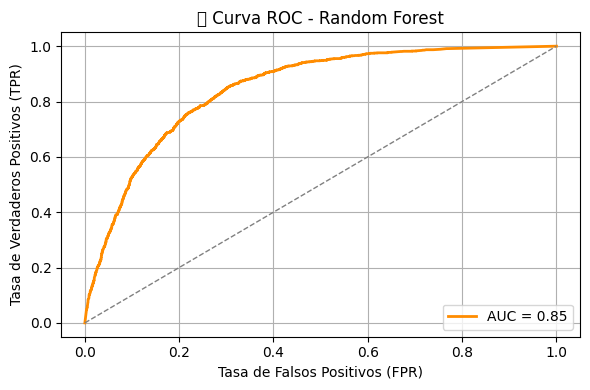

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Asegúrate de tener las probabilidades predichas
# Si ya lo hiciste antes, omite esta línea
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Dibujar curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("📈 Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
